# 01 · Exploración y Limpieza del Corpus

**Proyecto 3 — Chatbot Turístico con RAG + Fine-Tuning**
**Curso:** Minería de Textos — CUC

Corpus de reseñas turísticas de Costa Rica (Proyectos 1 y 2). Se limpia y se explora con las
herramientas estándar de pandas antes de pasarlo al pipeline RAG (notebook `02`).


## 1. Carga de datos

In [1]:
import re
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RUTA_PROYECTO = Path.cwd().resolve()
if not (RUTA_PROYECTO / "data").is_dir():
    RUTA_PROYECTO = RUTA_PROYECTO.parent

RUTA_CORPUS_ORIGINAL = RUTA_PROYECTO / "data" / "corpus_unificado.csv"
RUTA_CORPUS_LIMPIO = RUTA_PROYECTO / "data" / "corpus_resenas.csv"

df = pd.read_csv(RUTA_CORPUS_ORIGINAL)
df.shape


(5018, 7)

In [2]:
df.head()


,texto,calificacion,tipo_lugar,fuente,fecha,lugar,polaridad
0,"Tour fabuloso, bellísimo el bosque nuboso de M...",5.0,parque,civitatis,12/28/2020,Excursión a los puentes colgantes de Monteverde,positiva
1,Vale la pena ir a ver los puentes colgantes de...,4.0,parque,civitatis,08/08/2021,Excursión a los puentes colgantes de Monteverde,positiva
2,"La actividad es muy bonita, sin embargo hay do...",4.0,parque,civitatis,09/15/2022,Excursión a los puentes colgantes de Monteverde,positiva
3,No fui a este tour sino al del.volcan poas 100...,5.0,parque,civitatis,10/29/2025,Excursión a los puentes colgantes de Monteverde,positiva
4,"Muy interesante todo el recorrido, con la visi...",4.0,parque,civitatis,01/13/2024,Excursión al volcán Arenal + Aguas termales,positiva


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5018 entries, 0 to 5017
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   texto         5018 non-null   str    
 1   calificacion  5018 non-null   float64
 2   tipo_lugar    5018 non-null   str    
 3   fuente        5018 non-null   str    
 4   fecha         5018 non-null   str    
 5   lugar         5018 non-null   str    
 6   polaridad     5018 non-null   str    
dtypes: float64(1), str(6)
memory usage: 1.9 MB


In [4]:
df.describe(include="all")


,texto,calificacion,tipo_lugar,fuente,fecha,lugar,polaridad
count,5018,5018.000000,5018,5018,5018,5018,5018
unique,5018,NaN,7,2,309,212,3
top,"Tour fabuloso, bellísimo el bosque nuboso de M...",NaN,parque,google_maps,Hace un año,Hotel Las Brumas,positiva
freq,1,NaN,1724,4746,674,48,4404
mean,NaN,4.494420,NaN,NaN,NaN,NaN,NaN
std,NaN,0.989112,NaN,NaN,NaN,NaN,NaN
min,NaN,1.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,4.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,5.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,5.000000,NaN,NaN,NaN,NaN,NaN


## 2. Calidad de los datos

Nulos, duplicados y consistencia entre `calificacion` y `polaridad`, todo con métodos de pandas.

In [5]:
df.isnull().sum()


texto           0
calificacion    0
tipo_lugar      0
fuente          0
fecha           0
lugar           0
polaridad       0
dtype: int64

In [6]:
df.duplicated().sum()


np.int64(0)

In [7]:
# clave normalizada (minusculas, sin tildes, sin espacios extra) para detectar
# duplicados "casi exactos" que difieren solo en mayusculas/espacios/tildes
clave = (
    df["texto"].str.lower()
    .str.normalize("NFKD")
    .str.encode("ascii", errors="ignore")
    .str.decode("utf-8")
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
df.duplicated(subset=None).sum(), clave.duplicated().sum()


(np.int64(0), np.int64(0))

In [8]:
calificacion_vs_polaridad = pd.crosstab(df["calificacion"], df["polaridad"])
calificacion_vs_polaridad


polaridad,negativa,neutral,positiva
calificacion,,,
1.0,193,0,0
2.0,124,0,0
3.0,0,297,0
4.0,0,0,799
5.0,0,0,3605


## 3. Limpieza

Todo vectorizado con `.str`, sin recorrer el DataFrame fila por fila. Se conservan reseñas de dos o más palabras: expresiones como «muy bonito» o «excelente servicio» siguen siendo opiniones turísticas útiles.

El proyecto requiere entre 5,000 y 7,000 reseñas; por eso se valida ese rango después de eliminar duplicados.

In [9]:
EMOJI_PATTERN = r"[\U0001F1E6-\U0001FAFF\U00002600-\U000027BF\U00002B00-\U00002BFF\U0000FE0F\U0000200D]+"

df["texto"] = (
    df["texto"].astype("object")
    .str.replace(EMOJI_PATTERN, "", regex=True)   # emojis
    .str.replace(r"[\r\t]+", " ", regex=True)    # tabs y retornos de carro
    .str.replace(r"\n{3,}", "\n\n", regex=True) # conserva separacion de parrafos
    .str.replace(r"[^\S\n]{2,}", " ", regex=True) # espacios dobles, sin borrar saltos de linea
    .str.strip()
)

df["clave_normalizada"] = (
    df["texto"].str.lower()
    .str.normalize("NFKD")
    .str.encode("ascii", errors="ignore")
    .str.decode("utf-8")
)

df["n_palabras"] = df["texto"].str.split().str.len()

df.shape


(5018, 9)

In [10]:
# «Muy bonito» y «excelente servicio» son reseñas breves, pero informativas.
MIN_PALABRAS = 2
antes = len(df)
muy_cortas = df["n_palabras"] < MIN_PALABRAS
duplicadas = df.duplicated(subset="clave_normalizada", keep="first")

df = df.loc[~muy_cortas & ~duplicadas].copy()

# recalcula polaridad a partir de la calificacion, de forma vectorizada
df["polaridad"] = np.select(
    [df["calificacion"] <= 2, df["calificacion"] == 3, df["calificacion"] >= 4],
    ["negativa", "neutral", "positiva"],
    default="",
)

df = df.drop(columns="clave_normalizada")

print(f"Filas antes: {antes} -> despues: {len(df)}")
print(f"Descartadas por menos de {MIN_PALABRAS} palabras: {muy_cortas.sum()}")
print(f"Duplicados normalizados descartados: {duplicadas.sum()}")

if not 5_000 <= len(df) <= 7_000:
    raise ValueError(f"El corpus limpio debe contener entre 5,000 y 7,000 reseñas; contiene {len(df):,}.")
print(f"✓ Corpus válido para el proyecto: {len(df):,} reseñas.")


Filas antes: 5018 -> despues: 5018
Descartadas por menos de 2 palabras: 0
Duplicados normalizados descartados: 0
✓ Corpus válido para el proyecto: 5,018 reseñas.


In [11]:
RUTA_CORPUS_LIMPIO.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(RUTA_CORPUS_LIMPIO, index=False)
df.shape


(5018, 8)

## 4. Estadísticas básicas

In [12]:
df["tipo_lugar"].value_counts()


tipo_lugar
parque                 1724
hotel                   927
restaurante             912
museo                   543
tour_aventura           362
atraccion_turistica     338
mercado                 212
Name: count, dtype: int64

In [13]:
df["polaridad"].value_counts(normalize=True) * 100


polaridad
positiva    87.764049
negativa     6.317258
neutral      5.918693
Name: proportion, dtype: float64

In [14]:
df.groupby("tipo_lugar")["calificacion"].agg(["mean", "median", "count"])


,mean,median,count
tipo_lugar,,,
atraccion_turistica,4.470414,5.0,338
hotel,4.085221,5.0,927
mercado,4.608491,5.0,212
museo,4.699816,5.0,543
parque,4.586427,5.0,1724
restaurante,4.464912,5.0,912
tour_aventura,4.825967,5.0,362


In [15]:
df["n_palabras"].describe()


count    5018.000000
mean       45.757473
std        46.114930
min         2.000000
25%        18.000000
50%        33.000000
75%        58.000000
max       612.000000
Name: n_palabras, dtype: float64

In [16]:
df["lugar"].value_counts().head(10)


lugar
Hotel Las Brumas                        48
Rancho Camurí                           48
Parque Nacional Manuel Antonio          48
Parque Nacional Carara                  48
Reserva Natural Absoluta Cabo Blanco    48
Parque Nacional Volcán Arenal           48
Parque Marino del Pacífico              48
Parque Nacional Barra Honda             48
Parque Nacional La Cangreja             48
Parque Nacional Tapantí                 48
Name: count, dtype: int64

## 5. Gráficos

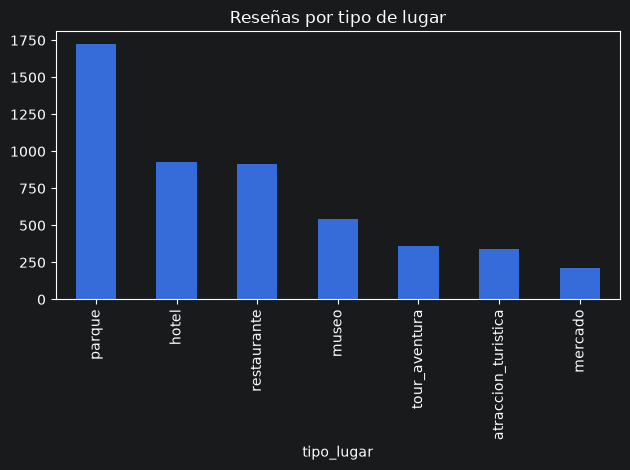

In [17]:
df["tipo_lugar"].value_counts().plot(kind="bar", title="Reseñas por tipo de lugar")
plt.tight_layout()
plt.show()


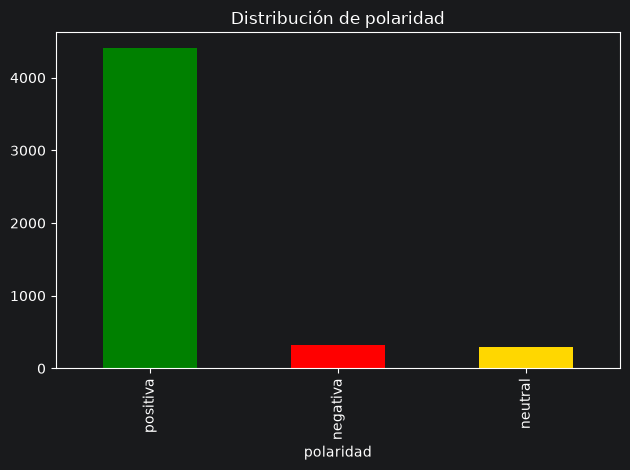

In [18]:
df["polaridad"].value_counts().plot(kind="bar", title="Distribución de polaridad", color=["green", "red", "gold"])
plt.tight_layout()
plt.show()


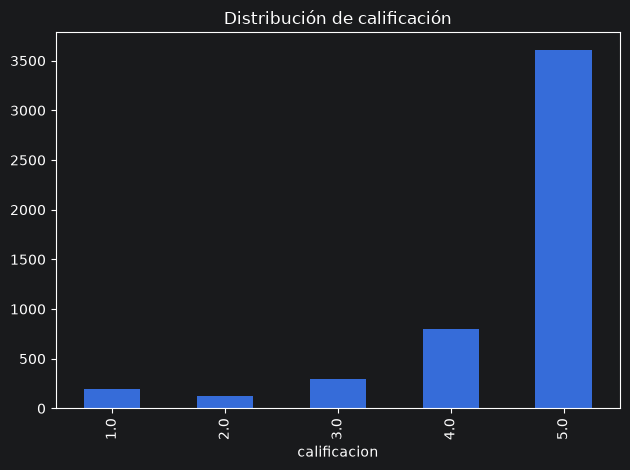

In [19]:
df["calificacion"].value_counts().sort_index().plot(kind="bar", title="Distribución de calificación")
plt.tight_layout()
plt.show()


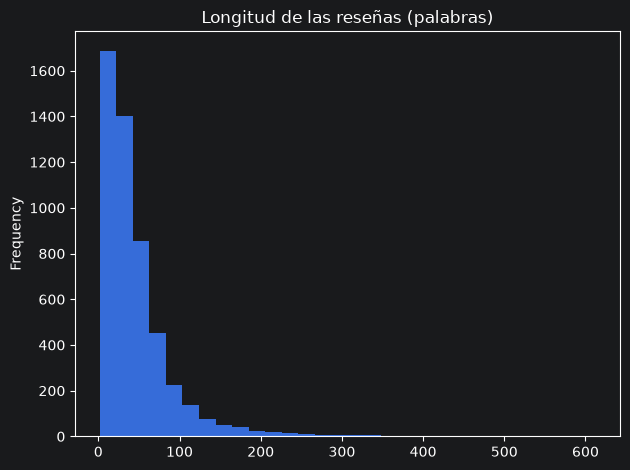

In [20]:
df["n_palabras"].plot(kind="hist", bins=30, title="Longitud de las reseñas (palabras)")
plt.tight_layout()
plt.show()


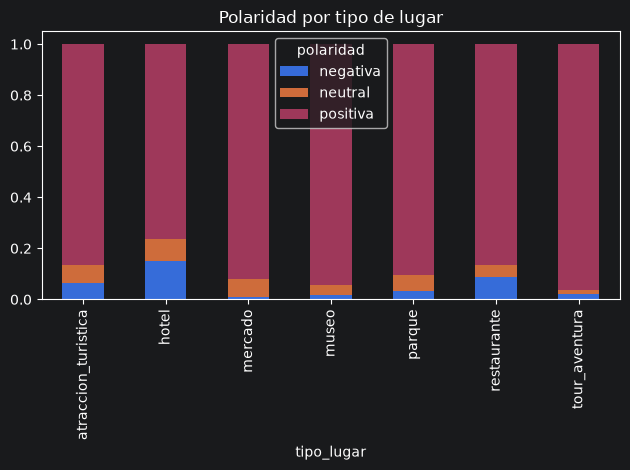

In [21]:
pd.crosstab(df["tipo_lugar"], df["polaridad"], normalize="index").plot(kind="bar", stacked=True, title="Polaridad por tipo de lugar")
plt.tight_layout()
plt.show()


## Cumplimiento del corpus y línea de investigación

El corpus limpio contiene **5,018 reseñas**, por lo que cumple el rango solicitado de 5,000 a 7,000. Incluye siete tipos de lugar —atracción turística, hotel, mercado, museo, parque, restaurante y tour de aventura—; supera así el mínimo de tres categorías. Todas las reseñas conservan `texto`, `calificacion`, `tipo_lugar`, `fuente` y `fecha`, y además incluyen `lugar`, `polaridad` y `n_palabras`.

Se adopta la **línea A: tipo de lugar**. TicoGuía es un experto en destinos de Costa Rica: el clasificador fine-tuneado predice el tipo de lugar y el chatbot usa esa predicción para filtrar los chunks del RAG antes de responder. Esto permite recomendar y describir hoteles, parques, restaurantes y otros destinos usando solamente reseñas del tipo correspondiente.

Como limitaciones, la distribución no es uniforme: predominan los parques y las calificaciones de cinco estrellas. Estas características se consideran al interpretar las métricas del clasificador y las recomendaciones, y se reportarán como parte del análisis final.